# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan

- Nama: Kristanto Winata
- Email: kristanto.winata@binus.ac.id
- Id Dicoding: kristanto_winata95bh

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


### Menyiapkan data yang akan diguankan

Sumber data: https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success (dataset publik "Predict Students' Dropout and Academic Success", UCI Machine Learning Repository, Realinho et al., 2021), dimuat dari mirror CSV publik agar bisa langsung diakses lewat URL.

In [2]:
url = "https://raw.githubusercontent.com/baiq99/deploy-streamlit/main/data.csv"
df = pd.read_csv(url, sep=";", encoding="utf-8-sig")
print(df.shape)
df.head()


(4424, 37)


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   int64  
 10 

In [4]:
df.isnull().sum().sum()


np.int64(0)

**Distribusi status siswa (target)**

In [5]:
df["Status"].value_counts()


Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

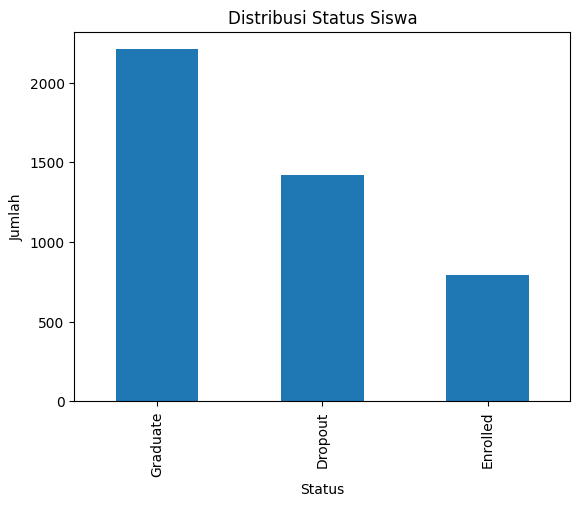

In [6]:
df["Status"].value_counts().plot(kind="bar")
plt.title("Distribusi Status Siswa")
plt.ylabel("Jumlah")
plt.show()


**Status berdasarkan jumlah mata kuliah lulus semester 2**

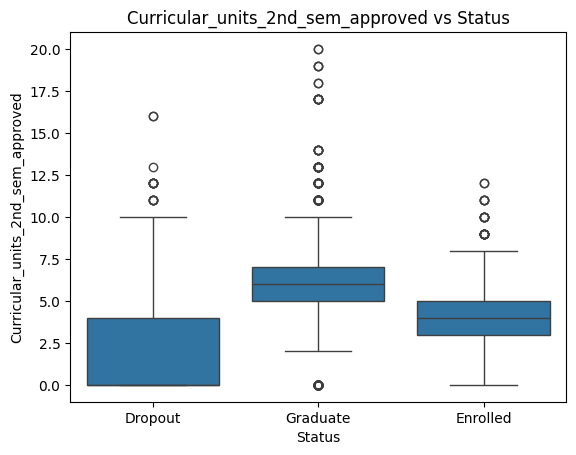

In [7]:
sns.boxplot(data=df, x="Status", y="Curricular_units_2nd_sem_approved")
plt.title("Curricular_units_2nd_sem_approved vs Status")
plt.show()


**Status berdasarkan status pembayaran uang kuliah**

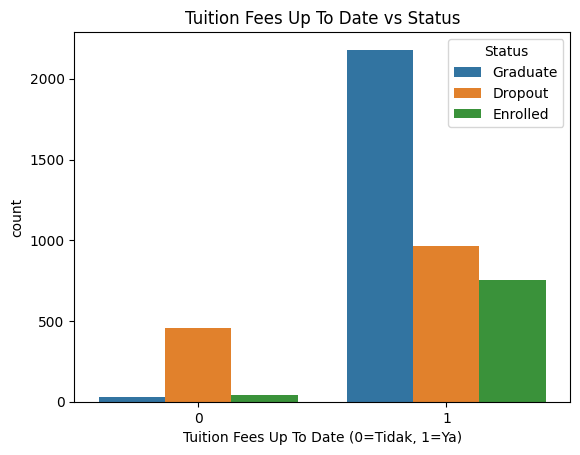

In [8]:
sns.countplot(data=df, x="Tuition_fees_up_to_date", hue="Status")
plt.title("Tuition Fees Up To Date vs Status")
plt.xlabel("Tuition Fees Up To Date (0=Tidak, 1=Ya)")
plt.show()


**Status berdasarkan status penerima beasiswa**

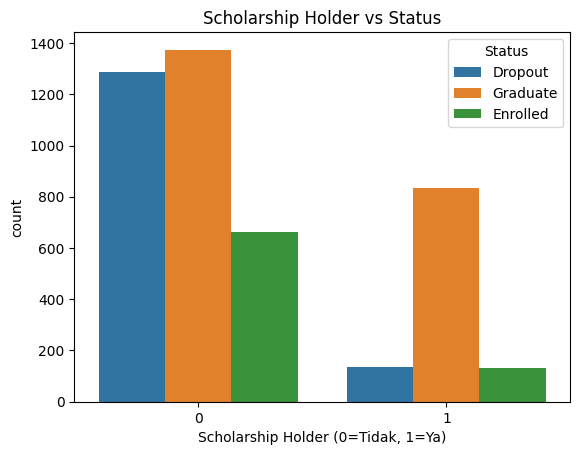

In [9]:
sns.countplot(data=df, x="Scholarship_holder", hue="Status")
plt.title("Scholarship Holder vs Status")
plt.xlabel("Scholarship Holder (0=Tidak, 1=Ya)")
plt.show()


**Status berdasarkan usia saat mendaftar**

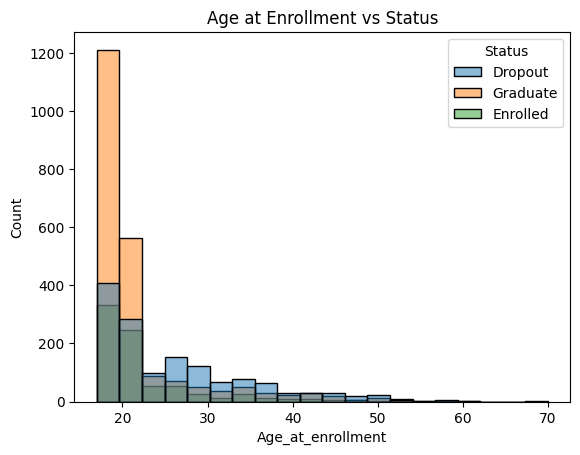

In [10]:
sns.histplot(data=df, x="Age_at_enrollment", hue="Status", bins=20)
plt.title("Age at Enrollment vs Status")
plt.show()


**Status berdasarkan nilai penerimaan (admission grade)**

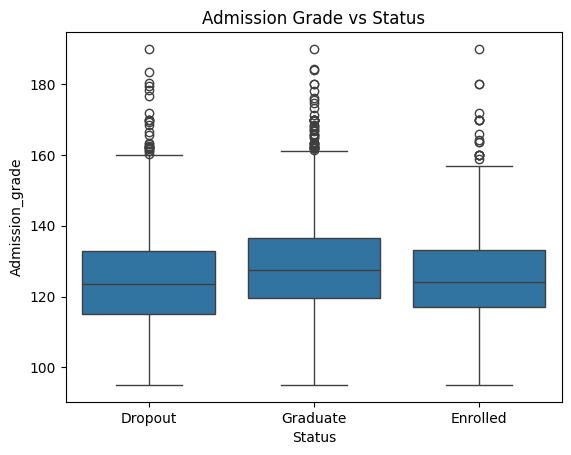

In [11]:
sns.boxplot(data=df, x="Status", y="Admission_grade")
plt.title("Admission Grade vs Status")
plt.show()


**Insight:** siswa berstatus Dropout cenderung punya jumlah mata kuliah lulus (approved) yang jauh lebih sedikit di semester 1 maupun 2, lebih banyak yang belum melunasi uang kuliah tepat waktu, dan proporsinya lebih tinggi pada siswa non-penerima beasiswa.

## Data Preparation / Preprocessing

1. Cek missing value — tidak ditemukan missing value pada dataset ini (data sudah bersih dari sumbernya).
2. Simpan salinan data bersih (`students_data_clean.csv`) untuk keperluan business dashboard.
3. Siapkan dua kelompok fitur:
   - **Seluruh fitur** (35 kolom) — dipakai untuk model analisis utama pada notebook ini.
   - **12 fitur terkurasi** (fitur dengan pengaruh terbesar berdasarkan feature importance, dan mudah diisi pengguna) — dipakai khusus untuk model yang di-deploy ke prototype Streamlit, supaya form input tidak terlalu panjang bagi pengguna.
4. Data dibagi 80% latih dan 20% uji, dengan `stratify=Status` karena distribusi kelas Status tidak seimbang.

In [12]:
df.to_csv("students_data_clean.csv", index=False)

X = df.drop(columns=["Status"])
y = df["Status"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)


(3539, 36) (885, 36)


In [13]:
selected_features = [
    "Curricular_units_2nd_sem_approved",
    "Curricular_units_2nd_sem_grade",
    "Curricular_units_1st_sem_approved",
    "Curricular_units_1st_sem_grade",
    "Admission_grade",
    "Tuition_fees_up_to_date",
    "Age_at_enrollment",
    "Curricular_units_2nd_sem_evaluations",
    "Previous_qualification_grade",
    "Curricular_units_1st_sem_evaluations",
    "Scholarship_holder",
    "Debtor",
]

X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]
X_train_sel.head()


,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Admission_grade,Tuition_fees_up_to_date,Age_at_enrollment,Curricular_units_2nd_sem_evaluations,Previous_qualification_grade,Curricular_units_1st_sem_evaluations,Scholarship_holder,Debtor
2283,10,11.800000,10,12.400000,118.6,1,21,13,120.0,14,0,0
3874,0,0.000000,0,0.000000,120.0,0,41,5,133.1,5,0,1
2281,4,10.500000,4,11.750000,140.0,1,21,15,140.0,13,0,0
817,6,12.833333,6,14.500000,120.8,1,18,6,125.0,6,0,0
404,7,14.731429,7,14.731429,131.3,1,19,8,142.0,8,0,0


## Modeling

Dibangun dua model `RandomForestClassifier` (`n_estimators=200`, `random_state=42`, parameter lain default):
1. **Model utama** — dilatih dengan seluruh 35 fitur, dipakai untuk analisis pada notebook ini (feature importance, evaluasi menyeluruh).
2. **Model deployment** — dilatih hanya dengan 12 fitur terkurasi, disimpan ke folder `model/` untuk dipakai prototype Streamlit (`app.py`).

In [14]:
rf_full = RandomForestClassifier(n_estimators=200, random_state=42)
rf_full.fit(X_train, y_train)
print("Model utama selesai dilatih.")


Model utama selesai dilatih.


In [15]:
rf_deploy = RandomForestClassifier(n_estimators=200, random_state=42)
rf_deploy.fit(X_train_sel, y_train)
print("Model deployment selesai dilatih.")


Model deployment selesai dilatih.


In [16]:
joblib.dump(rf_deploy, "model/model.joblib")
joblib.dump(selected_features, "model/selected_features.joblib")
print("Model dan daftar fitur disimpan ke folder model/")


Model dan daftar fitur disimpan ke folder model/


## Evaluation

In [17]:
pred_full = rf_full.predict(X_test)
print("Accuracy model utama (35 fitur):", accuracy_score(y_test, pred_full))
print(classification_report(y_test, pred_full))


Accuracy model utama (35 fitur): 0.7649717514124293
              precision    recall  f1-score   support

     Dropout       0.80      0.75      0.77       284
    Enrolled       0.55      0.34      0.42       159
    Graduate       0.79      0.93      0.85       442

    accuracy                           0.76       885
   macro avg       0.71      0.67      0.68       885
weighted avg       0.75      0.76      0.75       885



In [18]:
pred_deploy = rf_deploy.predict(X_test_sel)
print("Accuracy model deployment (12 fitur):", accuracy_score(y_test, pred_deploy))
print(classification_report(y_test, pred_deploy))


Accuracy model deployment (12 fitur): 0.7480225988700565
              precision    recall  f1-score   support

     Dropout       0.77      0.74      0.75       284
    Enrolled       0.48      0.33      0.39       159
    Graduate       0.80      0.91      0.85       442

    accuracy                           0.75       885
   macro avg       0.68      0.66      0.66       885
weighted avg       0.73      0.75      0.73       885



**Confusion Matrix (model utama)**

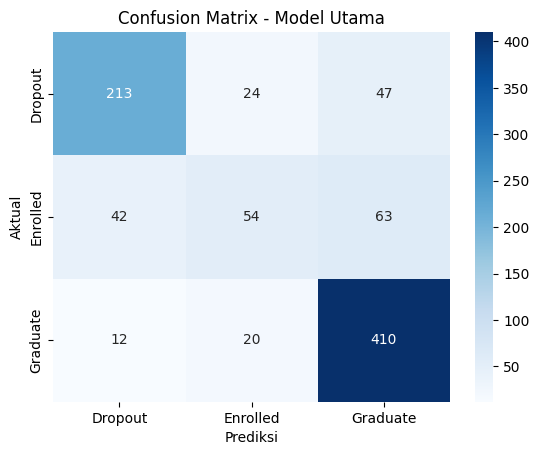

In [19]:
cm = confusion_matrix(y_test, pred_full, labels=rf_full.classes_)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=rf_full.classes_, yticklabels=rf_full.classes_)
plt.title("Confusion Matrix - Model Utama")
plt.ylabel("Aktual")
plt.xlabel("Prediksi")
plt.show()


**Feature Importance (model utama)** — 15 fitur paling berpengaruh:

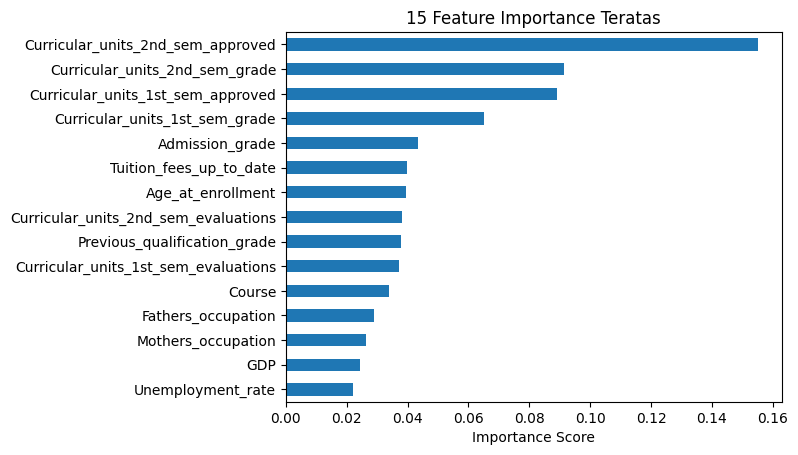

Curricular_units_2nd_sem_approved       0.155237
Curricular_units_2nd_sem_grade          0.091563
Curricular_units_1st_sem_approved       0.089231
Curricular_units_1st_sem_grade          0.065268
Admission_grade                         0.043532
Tuition_fees_up_to_date                 0.039944
Age_at_enrollment                       0.039607
Curricular_units_2nd_sem_evaluations    0.038053
Previous_qualification_grade            0.037818
Curricular_units_1st_sem_evaluations    0.037156
Course                                  0.033840
Fathers_occupation                      0.029014
Mothers_occupation                      0.026384
GDP                                     0.024333
Unemployment_rate                       0.021992
dtype: float64

In [20]:
importance = pd.Series(rf_full.feature_importances_, index=X.columns).sort_values(ascending=False)
importance.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("15 Feature Importance Teratas")
plt.xlabel("Importance Score")
plt.show()

importance.head(15)
